# GFS Wave forecast: Bondi Beach and Byron Bay

This notebook downloads the NOAA/NCEP **GFS Wave** global 0.25° forecast through the NOMADS GRIB2 subset service. It finds the nearest valid ocean grid cell to each beach (rather than assuming that the nearest grid coordinate is wet), plots the forecast, and writes a tidy CSV.

All files are kept in this notebook's folder under `data/` and `output/`. Wave direction is the direction waves come **from**, clockwise from true north. Times are UTC.

In [8]:
# Run once if this kernel does not already have the dependencies.
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
notebook 7.3.2 requires jupyterlab<4.4,>=4.3.4, but you have jupyterlab 4.4.4 which is incompatible.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [1]:
from pathlib import Path
from datetime import datetime, timezone, timedelta
import time
import numpy as np
import pandas as pd
import requests
import xarray as xr
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'output'
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

BEACHES = {
    'Bondi Beach': {'lat': -33.8915, 'lon': 151.2767},
    'Byron Bay':   {'lat': -28.6434, 'lon': 153.6122},
}

# Forecast hours: 0–120 h every 3 h. Extend to 384 if needed; GFS Wave
# output becomes 3-hourly/6-hourly depending on forecast range.
FORECAST_HOURS = list(range(0, 121, 3))
BBOX = {'leftlon': 150.0, 'rightlon': 155.0, 'bottomlat': -35.0, 'toplat': -27.0}
BASE_URL = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfswave.pl'
print(f'Working folder: {ROOT}')

Working folder: C:\Users\lachl\OneDrive - The University of Sydney (Staff)\Python_codes\surf_hororscopes


## Find and download the newest available model cycle

GFS runs at 00, 06, 12, and 18 UTC. Publication lags the nominal cycle time, so the code tries recent cycles and accepts the newest one for which forecast hour 0 is available. Each request is restricted to the coastal bounding box and five surface variables.

In [2]:
def cycle_candidates(hours_back=48):
    now = datetime.now(timezone.utc)
    latest_hour = (now.hour // 6) * 6
    first = now.replace(hour=latest_hour, minute=0, second=0, microsecond=0)
    return [first - timedelta(hours=6 * i) for i in range(hours_back // 6 + 1)]

def request_params(cycle, forecast_hour):
    file_name = f'gfswave.t{cycle:%H}z.global.0p25.f{forecast_hour:03d}.grib2'
    return {
        'file': file_name, 'lev_surface': 'on',
        'var_HTSGW': 'on', 'var_PERPW': 'on', 'var_DIRPW': 'on',
        'var_WIND': 'on', 'var_WDIR': 'on', 'subregion': '',
        **BBOX, 'dir': f'/gfs.{cycle:%Y%m%d}/{cycle:%H}/wave/gridded',
    }

def fetch_grib(cycle, forecast_hour, destination, retries=3):
    if destination.exists() and destination.stat().st_size > 1000:
        return destination
    last_error = None
    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=request_params(cycle, forecast_hour), timeout=90)
            response.raise_for_status()
            if len(response.content) < 1000 or response.content[:4] != b'GRIB':
                raise RuntimeError(f'No GRIB data returned ({len(response.content)} bytes)')
            destination.write_bytes(response.content)
            return destination
        except Exception as exc:
            last_error = exc
            time.sleep(2 ** attempt)
    raise RuntimeError(f'Failed f{forecast_hour:03d}: {last_error}')

cycle = None
for candidate in cycle_candidates():
    probe_dir = DATA_DIR / candidate.strftime('%Y%m%d_%H')
    probe_dir.mkdir(exist_ok=True)
    try:
        fetch_grib(candidate, 0, probe_dir / 'f000.grib2', retries=1)
        cycle = candidate
        break
    except Exception:
        continue
if cycle is None:
    raise RuntimeError('No recent GFS Wave cycle was available from NOMADS.')

cycle_dir = DATA_DIR / cycle.strftime('%Y%m%d_%H')
print('Using GFS Wave cycle:', cycle.isoformat())
grib_files = []
for i, hour in enumerate(FORECAST_HOURS, start=1):
    path = fetch_grib(cycle, hour, cycle_dir / f'f{hour:03d}.grib2')
    grib_files.append((hour, path))
    print(f'\rDownloaded/cached {i}/{len(FORECAST_HOURS)}', end='')
print()

Using GFS Wave cycle: 2026-08-21T06:00:00+00:00
Downloaded/cached 41/41


## Select the nearest offshore grid cells

The significant-wave-height field is missing over land. The selection below searches all valid cells in the downloaded coastal box and minimizes great-circle distance to each beach.

In [3]:
def open_grib(path):
    return xr.open_dataset(path, engine='cfgrib', backend_kwargs={'indexpath': ''})

def wave_height_name(ds):
    for name in ('swh', 'htsgw'):
        if name in ds.data_vars:
            return name
    candidates = [n for n, v in ds.data_vars.items() if 'significant height' in str(v.attrs).lower()]
    if not candidates:
        raise KeyError(f'Cannot identify wave-height field. Fields: {list(ds.data_vars)}')
    return candidates[0]

def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dl/2)**2
    return 6371.0 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

sample = open_grib(grib_files[0][1])
height_var = wave_height_name(sample)
field = sample[height_var].squeeze()
lat2d, lon2d = xr.broadcast(field.latitude, field.longitude)
valid = np.isfinite(field.values)
wet_lats = lat2d.values[valid]
wet_lons = lon2d.values[valid]

selected = {}
for name, beach in BEACHES.items():
    distances = haversine_km(beach['lat'], beach['lon'], wet_lats, wet_lons)
    j = int(np.argmin(distances))
    selected[name] = {'lat': float(wet_lats[j]), 'lon': float(wet_lons[j]),
                      'distance_km': float(distances[j])}
selection_table = pd.DataFrame(selected).T
selection_table.index.name = 'location'
display(selection_table.round(3))
sample.close()

,lat,lon,distance_km
location,,,
Bondi Beach,-34.00,151.25,12.313
Byron Bay,-28.75,153.75,17.921


## Extract a time series, save it, and plot it

In [4]:
ALIASES = {
    'wave_height_m': ('swh', 'htsgw'),
    'primary_period_s': ('perpw',),
    'primary_direction_deg': ('dirpw',),
    'wind_speed_m_s': ('ws', 'wind'),
    'wind_direction_deg': ('wdir',),
}

def scalar_at(ds, aliases, lat, lon):
    name = next((n for n in aliases if n in ds.data_vars), None)
    if name is None:
        return np.nan
    value = ds[name].sel(latitude=lat, longitude=lon, method='nearest').squeeze().values
    return float(value)

rows = []
for hour, path in grib_files:
    with open_grib(path) as ds:
        valid_time = pd.Timestamp(cycle) + pd.Timedelta(hours=hour)
        for location, point in selected.items():
            row = {
                'location': location, 'cycle_utc': pd.Timestamp(cycle),
                'forecast_hour': hour, 'valid_time_utc': valid_time,
                'grid_latitude': point['lat'], 'grid_longitude': point['lon'],
                'distance_from_beach_km': point['distance_km'],
            }
            for output_name, aliases in ALIASES.items():
                row[output_name] = scalar_at(ds, aliases, point['lat'], point['lon'])
            rows.append(row)

forecast = pd.DataFrame(rows).sort_values(['location', 'valid_time_utc'])
csv_path = OUTPUT_DIR / 'gfs_wave_bondi_byron.csv'
forecast.to_csv(csv_path, index=False)
print(f'Saved {len(forecast)} rows to {csv_path}')
display(forecast.head())

Saved 82 rows to C:\Users\lachl\OneDrive - The University of Sydney (Staff)\Python_codes\surf_hororscopes\output\gfs_wave_bondi_byron.csv


,location,cycle_utc,forecast_hour,valid_time_utc,grid_latitude,grid_longitude,distance_from_beach_km,wave_height_m,primary_period_s,primary_direction_deg,wind_speed_m_s,wind_direction_deg
0,Bondi Beach,2026-08-21 06:00:00+00:00,0,2026-08-21 06:00:00+00:00,-34.0,151.250006,12.313364,0.65,6.47,68.550003,3.37,35.790001
2,Bondi Beach,2026-08-21 06:00:00+00:00,3,2026-08-21 09:00:00+00:00,-34.0,151.250006,12.313364,0.59,6.41,66.680000,4.36,298.420013
4,Bondi Beach,2026-08-21 06:00:00+00:00,6,2026-08-21 12:00:00+00:00,-34.0,151.250006,12.313364,0.57,6.29,66.059998,4.64,265.299988
6,Bondi Beach,2026-08-21 06:00:00+00:00,9,2026-08-21 15:00:00+00:00,-34.0,151.250006,12.313364,0.51,6.32,67.580002,3.49,290.529999
8,Bondi Beach,2026-08-21 06:00:00+00:00,12,2026-08-21 18:00:00+00:00,-34.0,151.250006,12.313364,0.44,6.38,69.620003,2.97,288.799988


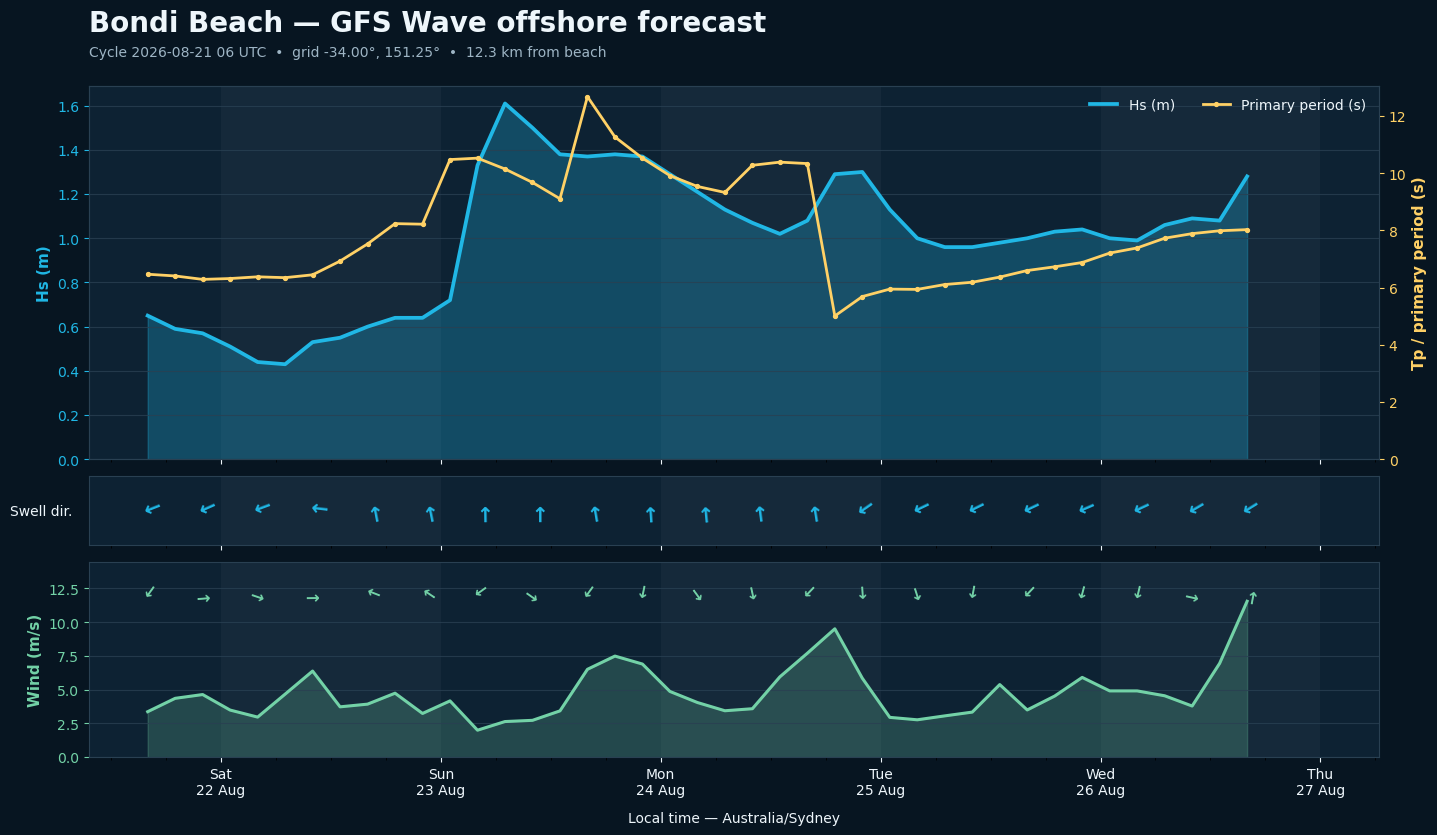

Saved: C:\Users\lachl\OneDrive - The University of Sydney (Staff)\Python_codes\surf_hororscopes\output\gfs_wave_bondi.png


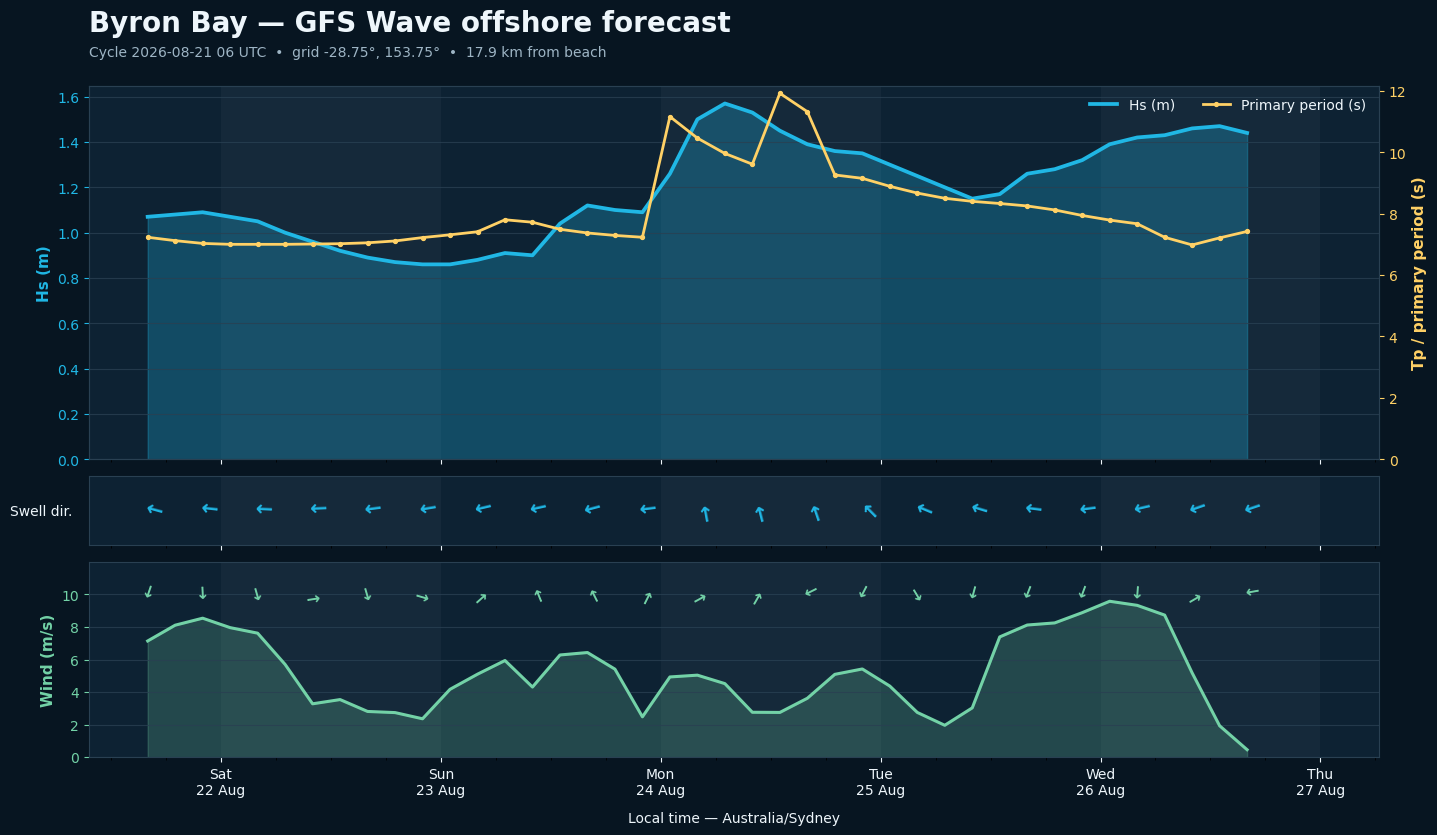

Saved: C:\Users\lachl\OneDrive - The University of Sydney (Staff)\Python_codes\surf_hororscopes\output\gfs_wave_byron_bay.png


In [5]:
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo

LOCAL_TZ = ZoneInfo('Australia/Sydney')
BG, PANEL, GRID = '#071521', '#0d2233', '#294052'
WAVE, PERIOD, WIND, TEXT = '#20b7e5', '#ffd166', '#73d2a7', '#eef6fb'

def add_day_shading(ax, times):
    # Alternating local-day bands make the multi-day forecast easier to scan.
    days = pd.date_range(times.min().normalize(), times.max().normalize() + pd.Timedelta(days=1), freq='D')
    for i in range(len(days) - 1):
        if i % 2:
            ax.axvspan(days[i], days[i + 1], color='white', alpha=0.035, lw=0)

def direction_arrows(ax, times, directions, color, every=2, size=13):
    # A down arrow at 0° points toward the south: waves/wind coming FROM north.
    for x, direction in zip(times.iloc[::every], directions.iloc[::every]):
        if pd.notna(direction):
            ax.text(x, 0.5, '↓', color=color, fontsize=size, ha='center', va='center',
                    rotation=-float(direction), rotation_mode='anchor', fontweight='bold')

def surfline_plot(location, group):
    g = group.sort_values('valid_time_utc').copy()
    g['local_time'] = pd.to_datetime(g.valid_time_utc, utc=True).dt.tz_convert(LOCAL_TZ)

    fig = plt.figure(figsize=(15, 8.5), facecolor=BG)
    gs = fig.add_gridspec(3, 1, height_ratios=[4.6, 0.85, 2.4], hspace=0.08)
    ax_wave = fig.add_subplot(gs[0])
    ax_dir = fig.add_subplot(gs[1], sharex=ax_wave)
    ax_wind = fig.add_subplot(gs[2], sharex=ax_wave)
    for ax in (ax_wave, ax_dir, ax_wind):
        ax.set_facecolor(PANEL)
        add_day_shading(ax, g.local_time)

    # Hs as a filled profile, with primary period (Tp-like model field) overlaid.
    ax_wave.fill_between(g.local_time, 0, g.wave_height_m, color=WAVE, alpha=0.28)
    hs_line, = ax_wave.plot(g.local_time, g.wave_height_m, color=WAVE, lw=2.7, label='Hs (m)')
    ax_tp = ax_wave.twinx()
    tp_line, = ax_tp.plot(g.local_time, g.primary_period_s, color=PERIOD, lw=2.0,
                          marker='o', ms=2.8, label='Primary period (s)')
    ax_wave.set_ylim(bottom=0)
    ax_tp.set_ylim(bottom=0)
    ax_wave.set_ylabel('Hs (m)', color=WAVE, fontsize=11, fontweight='bold')
    ax_tp.set_ylabel('Tp / primary period (s)', color=PERIOD, fontsize=11, fontweight='bold')
    ax_wave.tick_params(axis='y', colors=WAVE)
    ax_tp.tick_params(axis='y', colors=PERIOD)
    ax_wave.legend([hs_line, tp_line], ['Hs (m)', 'Primary period (s)'],
                   loc='upper right', frameon=False, ncol=2, labelcolor=TEXT)

    # Wave-direction strip. Arrows point where the waves travel; source values are FROM directions.
    direction_arrows(ax_dir, g.local_time, g.primary_direction_deg, WAVE, every=2, size=15)
    ax_dir.set_ylim(0, 1)
    ax_dir.set_yticks([])
    ax_dir.set_ylabel('Swell dir.', color=TEXT, rotation=0, ha='right', va='center', labelpad=12)

    # Local GFS Wave surface wind at the selected offshore cell.
    ax_wind.fill_between(g.local_time, 0, g.wind_speed_m_s, color=WIND, alpha=0.22)
    ax_wind.plot(g.local_time, g.wind_speed_m_s, color=WIND, lw=2.2)
    ax_wind.set_ylim(bottom=0)
    ax_wind.set_ylabel('Wind (m/s)', color=WIND, fontsize=11, fontweight='bold')
    ax_wind.tick_params(axis='y', colors=WIND)
    wind_top = max(float(g.wind_speed_m_s.max(skipna=True)) * 1.25, 2.0)
    ax_wind.set_ylim(0, wind_top)
    arrow_y = wind_top * 0.84
    for x, direction in zip(g.local_time.iloc[::2], g.wind_direction_deg.iloc[::2]):
        if pd.notna(direction):
            ax_wind.text(x, arrow_y, '↓', color=WIND, fontsize=12, ha='center', va='center',
                         rotation=-float(direction), rotation_mode='anchor', fontweight='bold')

    for ax in (ax_wave, ax_wind):
        ax.grid(axis='y', color=GRID, lw=0.8, alpha=0.8)
    for ax in (ax_wave, ax_dir, ax_wind, ax_tp):
        ax.tick_params(axis='x', colors=TEXT)
        for spine in ax.spines.values():
            spine.set_color(GRID)
    plt.setp(ax_wave.get_xticklabels(), visible=False)
    plt.setp(ax_dir.get_xticklabels(), visible=False)
    ax_wind.xaxis.set_major_locator(mdates.DayLocator(tz=LOCAL_TZ))
    ax_wind.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b', tz=LOCAL_TZ))
    ax_wind.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18], tz=LOCAL_TZ))
    ax_wind.set_xlabel('Local time — Australia/Sydney', color=TEXT, labelpad=10)

    point = selected[location]
    fig.suptitle(f'{location} — GFS Wave offshore forecast', x=0.07, ha='left',
                 color=TEXT, fontsize=20, fontweight='bold')
    fig.text(0.07, 0.925,
             f'Cycle {cycle:%Y-%m-%d %H} UTC  •  grid {point["lat"]:.2f}°, {point["lon"]:.2f}°  •  {point["distance_km"]:.1f} km from beach',
             color='#9eb5c5', fontsize=10)
    fig.subplots_adjust(left=0.07, right=0.93, top=0.89, bottom=0.10)

    slug = location.lower().replace(' beach', '').replace(' ', '_')
    plot_path = OUTPUT_DIR / f'gfs_wave_{slug}.png'
    fig.savefig(plot_path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print('Saved:', plot_path)
    return plot_path

plot_paths = {location: surfline_plot(location, group)
              for location, group in forecast.groupby('location', sort=False)}

## Generate current-condition surf horoscopes

The physical condition labels and horoscope prose are generated locally from curated Python templates. No API key, internet connection, language model, or special hardware is required.


In [6]:
import importlib
import surf_horoscope

# Reload so a running kernel cannot retain the earlier API-backed version.
surf_horoscope = importlib.reload(surf_horoscope)

# Inspect exactly what physical facts will be sent to the writing model.
current = surf_horoscope.current_rows(forecast)
condition_profiles = [surf_horoscope.interpret_conditions(row) for _, row in current.iterrows()]
display(pd.DataFrame(condition_profiles))

horoscope_reports = surf_horoscope.generate_all_horoscopes(forecast, OUTPUT_DIR)
for location, report in horoscope_reports.items():
    print(f'Generated {len(report.horoscopes)} offline horoscopes for {location}')
    display(pd.DataFrame([vars(item) for item in report.horoscopes]))


,location,valid_time_utc,wave_height_m,primary_period_s,wave_direction,wind_speed_m_s,wind_direction,wind_direction_deg,wind_quality,favourable_wind_rule,ocean_mood,height_feel,period_feel,ocean_feeling
0,Bondi Beach,2026-08-21 12:00:00+00:00,0.57,6.3,ENE,4.6,W,265,unfavourable,W to N,playful,"small and playful, rewarding timing more than ...","short-period and restless, with closely packed...","small and playful, rewarding timing more than ..."
1,Byron Bay,2026-08-21 12:00:00+00:00,1.09,7.0,E,8.5,N,357,unfavourable,SW to SE via S,lively,approachable but energetic enough for committe...,"short-period and restless, with closely packed...",approachable but energetic enough for committe...


Generated 12 offline horoscopes for Bondi Beach


,sign,headline,reading,surf_intention
0,Aries,Fire Meets Moving Water,"At Bondi Beach, the water carries a playful ch...",Pause for two sets before moving.
1,Taurus,Wait for the True Line,Today's ocean at Bondi Beach feels playful. Wi...,Wait for the wave with real shape.
2,Gemini,One Choice Among Many,The sea is speaking in playful tones at Bondi ...,Watch how the peak shifts.
3,Cancer,Let the Water Speak,"At Bondi Beach, the water carries a playful ch...",Trust the pattern you notice.
4,Leo,Confidence Without Performance,Today's ocean at Bondi Beach feels playful. Th...,Surf one wave with generous style.
5,Virgo,Refine the Take-off,"At Bondi Beach, the water carries a playful ch...",Refine one part of your take-off.
6,Libra,Effort Meets Ease,The sea is speaking in playful tones at Bondi ...,Share the peak and preserve your rhythm.
7,Scorpio,Meet Power Calmly,"At Bondi Beach, the water carries a playful ch...",Keep your breathing steady.
8,Sagittarius,A Wider Horizon Calls,"At Bondi Beach, the water carries a playful ch...",Leave room for an unexpected line.
9,Capricorn,Patience Builds the Session,The sea is speaking in playful tones at Bondi ...,Hold the patient position.


Generated 12 offline horoscopes for Byron Bay


,sign,headline,reading,surf_intention
0,Aries,Fire Meets Moving Water,The sea is speaking in lively tones at Byron B...,Choose one peak and commit.
1,Taurus,Wait for the True Line,The sea is speaking in lively tones at Byron B...,Settle into the rhythm.
2,Gemini,One Choice Among Many,The sea is speaking in lively tones at Byron B...,Watch how the peak shifts.
3,Cancer,Intuition Finds a Line,Today's ocean at Byron Bay feels lively. The c...,Take a quiet shoreline read.
4,Leo,Confidence Without Performance,The sea is speaking in lively tones at Byron B...,Make space as confidently as you take it.
5,Virgo,Refine the Take-off,The sea is speaking in lively tones at Byron B...,Refine one part of your take-off.
6,Libra,Balance Finds the Peak,The sea is speaking in lively tones at Byron B...,Share the peak and preserve your rhythm.
7,Scorpio,Meet Power Calmly,"At Byron Bay, the water carries a lively chara...",Keep your breathing steady.
8,Sagittarius,Explore with Respect,"At Byron Bay, the water carries a lively chara...",Leave room for an unexpected line.
9,Capricorn,Positioning Is the Work,"At Byron Bay, the water carries a lively chara...",Build the session one sound decision at a time.


### Notes

- This is an offshore deep-water model forecast, not a surf-height forecast at the beach. Nearshore bathymetry, refraction, sheltering, tides, and local winds can materially change breaking waves.
- NOAA source: [NCEP GFS Wave products](https://www.nco.ncep.noaa.gov/pmb/products/wave/) and [NOMADS GFS Wave filter](https://nomads.ncep.noaa.gov/cgi-bin/filter_gfswave.pl).
- Delete a cycle subfolder under `data/` if you want to force a clean re-download.